# Overlap Heatmaps

This notebook loads the narrowed overlap-filtered h5ads from `results/overlap_filtered_h5ads` and recomputes pairwise overlap counts using the same non-control sample-matching rule:

- identical `pubchem_cid`
- identical `cell_type`
- identical `pert_time_h`
- mutual nearest neighbors in `log10(pert_dose_uM)`
- `|Δ log10(dose)| <= 1`

Heatmaps summarize, for each dataset pair:

- matching drugs: unique `pubchem_cid` participating in at least one matched condition
- matching contexts: unique `cell_type` participating in at least one matched condition
- retained replicates / matching conditions: diagonal shows retained non-control replicate counts, while off-diagonal cells show matched dose-level conditions

For the third heatmap, one off-diagonal condition is counted per unique `pubchem_cid + cell_type + pert_time_h + dose-pair` match. So if `X, X'` in dataset A and `Y, Y'` in dataset B are replicate observations for the same matched dose pair, that contributes `1`, not `4`. Off-diagonal pairwise counts only include a `cell_type` context if that dataset pair shares at least 10 drugs in that context. DMSO controls present in the overlap h5ads are excluded from these heatmaps. Each heatmap is plotted in its own cell and saved as a separate PDF file.

In [112]:
from __future__ import annotations

from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "This notebook requires seaborn. Install with: uv add seaborn or pip install seaborn"
    ) from exc

sns.set_theme(context="talk", style="white")


In [113]:
DATASET_ORDER = [
    "l1000_phase1",
    "l1000_phase2",
    "novartis_batch_2500",
    "op3",
    "sciplex",
    "tahoe",
]
DISPLAY_LABELS = {
    "l1000_phase1": "L1000 Phase I",
    "l1000_phase2": "L1000 Phase II",
    "sciplex": "sci-Plex",
    "tahoe": "Tahoe-100M",
}
MAX_LOG10_DOSE_DIFF = 1.0
MIN_CONTEXT_SHARED_DRUGS = 10
NUMERIC_SIG_FIGS = 12


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results" / "overlap_filtered_h5ads").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()
OVERLAP_DIR = REPO_ROOT / "results" / "overlap_filtered_h5ads"
HEATMAP_PDF_PATHS = {
    "n_matching_drugs": OVERLAP_DIR / "overlap_matching_drugs_heatmap.pdf",
    "n_matching_contexts": OVERLAP_DIR / "overlap_matching_contexts_heatmap.pdf",
    "n_heatmap_condition_value": OVERLAP_DIR / "overlap_matching_sample_pairs_heatmap.pdf",
}

print(f"Repository root: {REPO_ROOT}")
print(f"Overlap directory: {OVERLAP_DIR}")
OVERLAP_DIR


Repository root: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis
Overlap directory: /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads


PosixPath('/ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads')

In [114]:
def format_numeric(value: float) -> str:
    formatted = f"{value:.{NUMERIC_SIG_FIGS}g}"
    return "0" if formatted == "-0" else formatted


def load_overlap_obs(dataset_name: str, overlap_dir: Path = OVERLAP_DIR) -> pd.DataFrame:
    h5ad_path = overlap_dir / f"{dataset_name}_overlap_filtered.h5ad"
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing overlap file: {h5ad_path}")

    adata = ad.read_h5ad(h5ad_path, backed="r")
    try:
        obs = adata.obs.copy()
    finally:
        adata.file.close()

    if obs.empty:
        return pd.DataFrame(
            columns=[
                "dataset_name",
                "obs_id",
                "pubchem_cid",
                "cell_type",
                "time_key",
                "dose_key",
                "log10_dose",
            ]
        )

    if "is_control" not in obs.columns:
        raise KeyError(f"{h5ad_path} is missing obs['is_control']")

    is_control = obs["is_control"]
    if pd.api.types.is_bool_dtype(is_control):
        control_mask = is_control.fillna(False).astype(bool)
    else:
        control_mask = (
            is_control.astype("string").fillna("").astype(str).str.strip().str.lower().isin(
                {"true", "1", "yes"}
            )
        )

    obs = obs.loc[~control_mask].copy()
    if obs.empty:
        return pd.DataFrame(
            columns=[
                "dataset_name",
                "obs_id",
                "pubchem_cid",
                "cell_type",
                "time_key",
                "dose_key",
                "log10_dose",
            ]
        )

    frame = pd.DataFrame(index=obs.index.copy())
    frame["dataset_name"] = dataset_name
    frame["obs_id"] = frame.index.astype(str)
    frame["pubchem_cid"] = obs["pubchem_cid"].astype("string").fillna("").astype(str).str.strip()
    frame["cell_type"] = obs["cell_type"].astype("string").fillna("").astype(str).str.strip()
    frame["pert_time_h"] = pd.to_numeric(obs["pert_time_h"], errors="coerce")
    frame["pert_dose_uM"] = pd.to_numeric(obs["pert_dose_uM"], errors="coerce")

    valid_mask = (
        (frame["pubchem_cid"] != "")
        & (frame["cell_type"] != "")
        & np.isfinite(frame["pert_time_h"].to_numpy(dtype=float))
        & np.isfinite(frame["pert_dose_uM"].to_numpy(dtype=float))
        & (frame["pert_dose_uM"].to_numpy(dtype=float) > 0.0)
    )
    frame = frame.loc[valid_mask].copy().reset_index(drop=True)
    frame["time_key"] = frame["pert_time_h"].map(lambda value: format_numeric(float(value)))
    frame["dose_key"] = frame["pert_dose_uM"].map(lambda value: format_numeric(float(value)))
    frame["log10_dose"] = np.log10(frame["pert_dose_uM"].to_numpy(dtype=np.float64))
    return frame[
        [
            "dataset_name",
            "obs_id",
            "pubchem_cid",
            "cell_type",
            "time_key",
            "dose_key",
            "log10_dose",
        ]
    ]


def build_groups(frame: pd.DataFrame) -> dict[tuple[str, str, str], np.ndarray]:
    if frame.empty:
        return {}
    grouped = frame.groupby(["pubchem_cid", "cell_type", "time_key"], sort=False).groups
    return {
        key: np.asarray(list(row_positions), dtype=np.int64)
        for key, row_positions in grouped.items()
    }


def build_dataset_index(dataset_name: str) -> dict[str, object]:
    frame = load_overlap_obs(dataset_name)
    return {
        "frame": frame,
        "groups": build_groups(frame),
    }


def mutual_nearest_logdose_pairs(
    left_log10_doses: np.ndarray,
    right_log10_doses: np.ndarray,
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> np.ndarray:
    if left_log10_doses.size == 0 or right_log10_doses.size == 0:
        return np.empty((0, 2), dtype=np.int64)

    diff = np.abs(left_log10_doses[:, None] - right_log10_doses[None, :])
    left_min = diff.min(axis=1, keepdims=True)
    right_min = diff.min(axis=0, keepdims=True)
    is_mnn = (
        (diff <= max_log10_dose_diff + 1e-12)
        & np.isclose(diff, left_min, rtol=0.0, atol=1e-12)
        & np.isclose(diff, right_min, rtol=0.0, atol=1e-12)
    )
    return np.argwhere(is_mnn)


def dataset_totals(dataset_index: dict[str, object]) -> dict[str, int]:
    frame = dataset_index["frame"]
    return {
        "n_matching_drugs": int(frame["pubchem_cid"].nunique()),
        "n_matching_contexts": int(frame["cell_type"].nunique()),
        "n_matching_conditions": int(
            frame[["pubchem_cid", "cell_type", "time_key", "dose_key"]]
            .drop_duplicates()
            .shape[0]
        ),
        "n_retained_replicates": int(len(frame)),
    }


def active_dataset_names(dataset_indices: dict[str, dict[str, object]]) -> list[str]:
    return [
        dataset_name
        for dataset_name in DATASET_ORDER
        if not dataset_indices[dataset_name]["frame"].empty
    ]


def pair_match_counts(
    left_dataset: str,
    right_dataset: str,
    left_index: dict[str, object],
    right_index: dict[str, object],
    max_log10_dose_diff: float = MAX_LOG10_DOSE_DIFF,
) -> dict[str, int | str]:
    left_frame = left_index["frame"]
    right_frame = right_index["frame"]
    left_groups = left_index["groups"]
    right_groups = right_index["groups"]

    shared_keys = sorted(set(left_groups) & set(right_groups))
    context_matching_drugs: dict[str, set[str]] = {}
    context_shared_condition_keys: dict[str, set[tuple[str, str, str]]] = {}
    context_matching_condition_keys: dict[str, set[tuple[str, str, str, str, str]]] = {}
    context_matching_observation_pairs: dict[str, int] = {}

    left_log10_dose = left_frame["log10_dose"].to_numpy(dtype=np.float64)
    right_log10_dose = right_frame["log10_dose"].to_numpy(dtype=np.float64)
    left_dose_keys = left_frame["dose_key"].to_numpy(dtype=object)
    right_dose_keys = right_frame["dose_key"].to_numpy(dtype=object)

    for pubchem_cid, cell_type, time_key in shared_keys:
        left_rows = left_groups[(pubchem_cid, cell_type, time_key)]
        right_rows = right_groups[(pubchem_cid, cell_type, time_key)]
        pairs = mutual_nearest_logdose_pairs(
            left_log10_doses=left_log10_dose[left_rows],
            right_log10_doses=right_log10_dose[right_rows],
            max_log10_dose_diff=max_log10_dose_diff,
        )
        if pairs.size == 0:
            continue

        context_key = str(cell_type)
        context_matching_drugs.setdefault(context_key, set()).add(str(pubchem_cid))
        context_shared_condition_keys.setdefault(context_key, set()).add(
            (str(pubchem_cid), str(cell_type), str(time_key))
        )
        context_matching_observation_pairs[context_key] = (
            context_matching_observation_pairs.get(context_key, 0) + int(len(pairs))
        )

        for left_pos, right_pos in pairs:
            context_matching_condition_keys.setdefault(context_key, set()).add(
                (
                    str(pubchem_cid),
                    str(cell_type),
                    str(time_key),
                    str(left_dose_keys[left_rows[left_pos]]),
                    str(right_dose_keys[right_rows[right_pos]]),
                )
            )

    qualifying_contexts = {
        context_key
        for context_key, compounds in context_matching_drugs.items()
        if len(compounds) >= MIN_CONTEXT_SHARED_DRUGS
    }

    matching_drugs: set[str] = set()
    matching_contexts: set[str] = set()
    shared_condition_keys: set[tuple[str, str, str]] = set()
    matching_condition_keys: set[tuple[str, str, str, str, str]] = set()
    n_matching_observation_pairs = 0
    for context_key in qualifying_contexts:
        matching_drugs.update(context_matching_drugs[context_key])
        matching_contexts.add(context_key)
        shared_condition_keys.update(context_shared_condition_keys[context_key])
        matching_condition_keys.update(context_matching_condition_keys.get(context_key, set()))
        n_matching_observation_pairs += context_matching_observation_pairs.get(context_key, 0)

    return {
        "dataset_a": left_dataset,
        "dataset_b": right_dataset,
        "n_shared_condition_keys": int(len(shared_condition_keys)),
        "n_matching_drugs": int(len(matching_drugs)),
        "n_matching_contexts": int(len(matching_contexts)),
        "n_matching_conditions": int(len(matching_condition_keys)),
        "n_matching_observation_pairs": int(n_matching_observation_pairs),
    }


def build_pairwise_summary(
    dataset_indices: dict[str, dict[str, object]],
    dataset_names: list[str],
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    drugs_matrix = pd.DataFrame(0, index=dataset_names, columns=dataset_names, dtype=int)
    contexts_matrix = pd.DataFrame(0, index=dataset_names, columns=dataset_names, dtype=int)
    sample_value_matrix = pd.DataFrame(0, index=dataset_names, columns=dataset_names, dtype=int)
    rows: list[dict[str, int | str]] = []

    for i, dataset_a in enumerate(dataset_names):
        totals = dataset_totals(dataset_indices[dataset_a])
        drugs_matrix.loc[dataset_a, dataset_a] = totals["n_matching_drugs"]
        contexts_matrix.loc[dataset_a, dataset_a] = totals["n_matching_contexts"]
        sample_value_matrix.loc[dataset_a, dataset_a] = totals["n_retained_replicates"]
        rows.append(
            {
                "dataset_a": dataset_a,
                "dataset_b": dataset_a,
                "n_shared_condition_keys": totals["n_matching_conditions"],
                "n_matching_drugs": totals["n_matching_drugs"],
                "n_matching_contexts": totals["n_matching_contexts"],
                "n_matching_conditions": totals["n_matching_conditions"],
                "n_matching_observation_pairs": totals["n_retained_replicates"],
                "n_heatmap_condition_value": totals["n_retained_replicates"],
            }
        )

        for dataset_b in dataset_names[i + 1 :]:
            counts = pair_match_counts(
                left_dataset=dataset_a,
                right_dataset=dataset_b,
                left_index=dataset_indices[dataset_a],
                right_index=dataset_indices[dataset_b],
            )
            counts["n_heatmap_condition_value"] = counts["n_matching_conditions"]
            rows.append(counts)

            drugs_matrix.loc[dataset_a, dataset_b] = counts["n_matching_drugs"]
            drugs_matrix.loc[dataset_b, dataset_a] = counts["n_matching_drugs"]
            contexts_matrix.loc[dataset_a, dataset_b] = counts["n_matching_contexts"]
            contexts_matrix.loc[dataset_b, dataset_a] = counts["n_matching_contexts"]
            sample_value_matrix.loc[dataset_a, dataset_b] = counts["n_matching_conditions"]
            sample_value_matrix.loc[dataset_b, dataset_a] = counts["n_matching_conditions"]

    summary = pd.DataFrame(rows).sort_values(["dataset_a", "dataset_b"]).reset_index(drop=True)
    heatmaps = {
        "n_matching_drugs": drugs_matrix,
        "n_matching_contexts": contexts_matrix,
        "n_heatmap_condition_value": sample_value_matrix,
    }
    return summary, heatmaps


def pretty_label(dataset_name: str) -> str:
    return DISPLAY_LABELS.get(dataset_name, dataset_name)


def relabel_matrix(matrix: pd.DataFrame) -> pd.DataFrame:
    return matrix.rename(index=pretty_label, columns=pretty_label)


def plot_metric_heatmap(
    metric_key: str,
    title: str,
    cmap: str,
    output_path: Path,
    *,
    hide_diagonal: bool = False,
    trim_obsolete_edges: bool = False,
) -> None:
    matrix = relabel_matrix(heatmaps[metric_key])
    if trim_obsolete_edges:
        matrix = matrix.iloc[1:, :-1]

    mask_offset = 0 if hide_diagonal else 1
    upper_triangle_mask = np.triu(np.ones(matrix.shape, dtype=bool), k=mask_offset)

    fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="g",
        cmap=cmap,
        mask=upper_triangle_mask,
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.8},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print(f"Saved {title} heatmap to {output_path}")


In [115]:
dataset_indices = {dataset_name: build_dataset_index(dataset_name) for dataset_name in DATASET_ORDER}
active_datasets = active_dataset_names(dataset_indices)
if not active_datasets:
    raise ValueError("No datasets with retained non-control matched samples were found.")

pairwise_summary, heatmaps = build_pairwise_summary(dataset_indices, active_datasets)

print("Datasets shown:", ", ".join(pretty_label(name) for name in active_datasets))
print(
    f"Off-diagonal pairwise counts include a cell_type context only when the dataset pair shares at least {MIN_CONTEXT_SHARED_DRUGS} drugs in that context. "
)
print(
    "Off-diagonal counts in the third heatmap are matched dose-level conditions. "
    "A condition is counted once per shared pubchem_cid + cell_type + pert_time_h + matched dose-pair, "
    "even if multiple replicate observation pairs support it. "
    "The diagonal is omitted there, and the empty first row / last column are trimmed."
)

pairwise_summary_display = pairwise_summary.copy()
pairwise_summary_display["dataset_a"] = pairwise_summary_display["dataset_a"].map(pretty_label)
pairwise_summary_display["dataset_b"] = pairwise_summary_display["dataset_b"].map(pretty_label)
display(pairwise_summary_display)


Datasets shown: L1000 Phase I, L1000 Phase II, sci-Plex, Tahoe-100M
Off-diagonal pairwise counts include a cell_type context only when the dataset pair shares at least 10 drugs in that context. 
Off-diagonal counts in the third heatmap are matched dose-level conditions. A condition is counted once per shared pubchem_cid + cell_type + pert_time_h + matched dose-pair, even if multiple replicate observation pairs support it. The diagonal is omitted there, and the empty first row / last column are trimmed.


,dataset_a,dataset_b,n_shared_condition_keys,n_matching_drugs,n_matching_contexts,n_matching_conditions,n_matching_observation_pairs,n_heatmap_condition_value
0,L1000 Phase I,L1000 Phase I,623,284,4,623,2817,2817
1,L1000 Phase I,L1000 Phase II,232,190,3,375,10855,375
2,L1000 Phase I,sci-Plex,165,90,2,291,2695,291
3,L1000 Phase I,Tahoe-100M,114,86,3,152,610,152
4,L1000 Phase II,L1000 Phase II,977,298,3,977,3866,3866
5,L1000 Phase II,sci-Plex,127,83,2,381,3192,381
6,L1000 Phase II,Tahoe-100M,134,110,2,402,1473,402
7,sci-Plex,sci-Plex,545,122,2,545,1096,1096
8,sci-Plex,Tahoe-100M,23,23,1,69,170,69
9,Tahoe-100M,Tahoe-100M,563,143,3,563,650,650


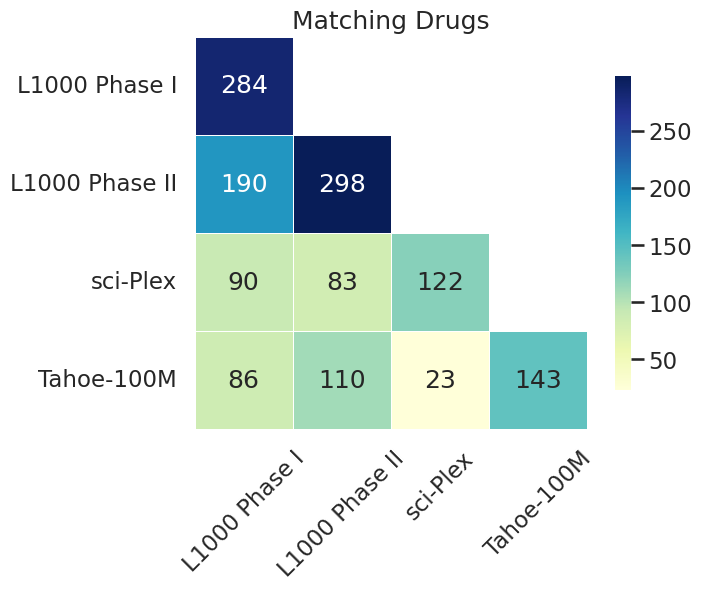

Saved Matching Drugs heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads/overlap_matching_drugs_heatmap.pdf


In [116]:
plot_metric_heatmap(
    metric_key="n_matching_drugs",
    title="Matching Drugs",
    cmap="YlGnBu",
    output_path=HEATMAP_PDF_PATHS["n_matching_drugs"],
)


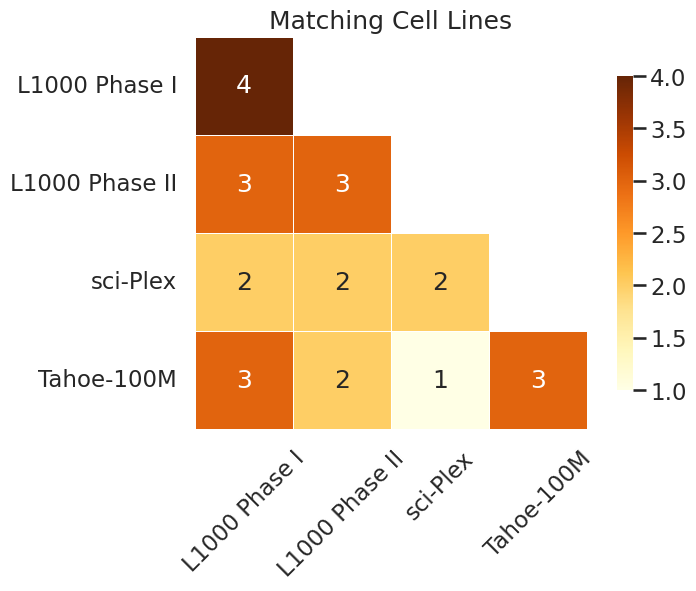

Saved Matching Cell Lines heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads/overlap_matching_contexts_heatmap.pdf


In [117]:
plot_metric_heatmap(
    metric_key="n_matching_contexts",
    title="Matching Cell Lines",
    cmap="YlOrBr",
    output_path=HEATMAP_PDF_PATHS["n_matching_contexts"],
)


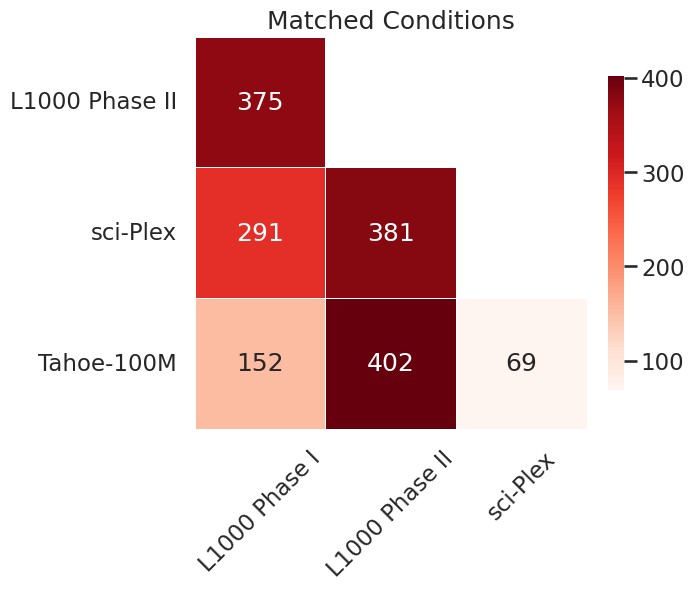

Saved Matched Conditions heatmap to /ictstr01/groups/ml01/workspace/artur.szalata/code/op3_analysis/results/overlap_filtered_h5ads/overlap_matching_sample_pairs_heatmap.pdf


In [122]:
plot_metric_heatmap(
    metric_key="n_heatmap_condition_value",
    title="Matched Conditions",
    cmap="Reds",
    output_path=HEATMAP_PDF_PATHS["n_heatmap_condition_value"],
    # hide_diagonal=True,
    trim_obsolete_edges=True,
)
